In [1]:
# PARTE 1 - PARÂMETROS & IMPORTS

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Concatenate, GlobalAveragePooling2D,
    Dense, LayerNormalization, Dropout, Lambda, Add, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU, SparseCategoricalAccuracy

from tqdm import tqdm
import scipy.signal
import pickle

# ---- Caminhos dos dados ----
PATH_INPUT       = 'treino_fft_aisotropic.npy'
PATH_LABEL       = 'Sismica/train/Output/seismic_TRAIN_LABEL_crops.npy'
PATH_TEST_INPUT  = 'teste_fft_aisotropic.npy'

# ---- Configurações do Modelo ----
# Aqui o input final será (H, W, 3) após a engenharia de atributos
NUM_CLASSES = 6                 # classes de SEGMENTAÇÃO
EMB_DIM     = 128               # dimensão do embedding

# ---- Configurações de Treinamento ----
BATCH_SIZE  = 8
EPOCHS      = 20
VAL_SPLIT   = 0.15
LEARNING_RATE = 1e-3

# ---- Configurações de Saída ----
MODEL_SAVE_PATH   = 'unet_sismico_Attention_best_model__v2_teste.keras'
HISTORY_SAVE_PATH = 'history_attention_unet_fft_aniso_v2.pkl'
NPZ_SAVE_PATH     = 'predictions_A-Unet__teste_v2.npz'

# GPU (opcional)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs disponíveis: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("NENHUMA GPU ENCONTRADA. Treinamento será em CPU.")

print("TF version:", tf.__version__)


2025-11-14 17:07:10.712176: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-14 17:07:10.801959: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-14 17:07:12.579459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.20.0


In [2]:
# =======================================
# PARTE 2 - CARREGAMENTO DOS DADOS
# =======================================
print("Carregando dados de treino...")
try:
    seismic_amplitude = np.load(PATH_INPUT)        # esperado: (N, H, W)
    seismic_labels    = np.load(PATH_LABEL)# esperado: (N, H, W)
    
    print(f"Dados de amplitude carregados. Shape: {seismic_amplitude.shape}, dtype: {seismic_amplitude.dtype}")
    print(f"Dados de rótulos carregados.   Shape: {seismic_labels.shape},    dtype: {seismic_labels.dtype}")
except FileNotFoundError:
    raise FileNotFoundError(
        "ERRO: Arquivo não encontrado.\n"
        f"Verifique PATH_INPUT = {PATH_INPUT}\n"
        f"e PATH_LABEL = {PATH_LABEL}"
    )

print("Carregando dados de teste...")
try:
    seismic_test = np.load(PATH_TEST_INPUT)  # esperado: (N_test, H, W)
    print(f"Dados de teste carregados. Shape: {seismic_test.shape}, dtype: {seismic_test.dtype}")
except FileNotFoundError:
    print("AVISO: PATH_TEST_INPUT não encontrado. Teste será ignorado.")
    seismic_test = None

# Garantir tipos dos rótulos
seismic_labels = seismic_labels.astype(np.int32)

# Conferir número de classes a partir dos rótulos
unique_labels = np.unique(seismic_labels)
print("Valores únicos nas labels:", unique_labels)
NUM_CLASSES = int(unique_labels.max() + 1)
print("NUM_CLASSES ajustado para:", NUM_CLASSES)


Carregando dados de treino...
Dados de amplitude carregados. Shape: (18830, 224, 224), dtype: float32
Dados de rótulos carregados.   Shape: (18830, 224, 224),    dtype: int32
Carregando dados de teste...
Dados de teste carregados. Shape: (4700, 224, 224), dtype: float32
Valores únicos nas labels: [0 1 2 3 4 5]
NUM_CLASSES ajustado para: 6


In [3]:
# ENGENHARIA DE ATRIBUTOS

def create_multi_channel_data(amplitude_data):
    if amplitude_data.ndim != 3:
        raise ValueError(f"Esperado (N,H,W), mas recebi {amplitude_data.shape}")
    
    num_samples, height, width = amplitude_data.shape
    output_data = np.zeros((num_samples, height, width, 3), dtype=np.float32)
    
    print(f"Iniciando geração de atributos para {num_samples} amostras...")
    
    for i in tqdm(range(num_samples)):
        img_amp = amplitude_data[i]  # (H, W)
        
        # 2. Transformada de Hilbert ao longo do eixo 0 (profundidade)
        analytic_signal = scipy.signal.hilbert(img_amp, axis=0)
        
        # 3. Envelope
        envelope = np.abs(analytic_signal)
        
        # 4. Z-score do envelope
        mean_env = np.mean(envelope)
        std_env  = np.std(envelope)
        if std_env == 0:
            std_env = 1.0
        norm_env = (envelope - mean_env) / std_env
        
        # 5. Cosseno da fase
        cosine_phase = np.cos(np.angle(analytic_signal))
        
        # 6. Empilhar canais
        output_data[i, :, :, 0] = img_amp.astype(np.float32)
        output_data[i, :, :, 1] = norm_env.astype(np.float32)
        output_data[i, :, :, 2] = cosine_phase.astype(np.float32)
        
    print("Geração de atributos concluída.")
    return output_data

# Processa dados de treino
X_train_multi_channel = create_multi_channel_data(seismic_amplitude)

# Otimização de memória
print("Limpando o array de amplitude original da memória...")
del seismic_amplitude

print(f"Shape final X_train_multi_channel: {X_train_multi_channel.shape}")
print(f"Shape final seismic_labels:        {seismic_labels.shape}")

# Se existir teste, processa também
if seismic_test is not None:
    X_test_multi_channel = create_multi_channel_data(seismic_test)
    del seismic_test
    print("Shape X_test_multi_channel:", X_test_multi_channel.shape)
else:
    X_test_multi_channel = None

INPUT_SHAPE = X_train_multi_channel.shape[1:]   # (H, W, 3)
print("INPUT_SHAPE definido como:", INPUT_SHAPE)


Iniciando geração de atributos para 18830 amostras...


100%|██████████| 18830/18830 [00:27<00:00, 686.37it/s]


Geração de atributos concluída.
Limpando o array de amplitude original da memória...
Shape final X_train_multi_channel: (18830, 224, 224, 3)
Shape final seismic_labels:        (18830, 224, 224)
Iniciando geração de atributos para 4700 amostras...


100%|██████████| 4700/4700 [00:04<00:00, 1128.50it/s]

Geração de atributos concluída.
Shape X_test_multi_channel: (4700, 224, 224, 3)
INPUT_SHAPE definido como: (224, 224, 3)


In [4]:
# =======================================
# PARTE 4 - FOCAL LOSS E BLOCOS
# =======================================

# 4a. Função de Perda (Sparse Focal Loss)
def create_focal_loss(gamma=2.0, alpha=0.25):
    def sparse_focal_loss(y_true, y_pred):
        """
        y_true: (N,H,W) com inteiros [0..C-1]
        y_pred: logits (N,H,W,C)
        """
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        
        p = tf.nn.softmax(y_pred, axis=-1)
        p = tf.clip_by_value(p, 1e-7, 1. - 1e-7)
        
        ce_loss = -y_true_one_hot * tf.math.log(p)
        p_t = tf.reduce_sum(y_true_one_hot * p, axis=-1)
        focal_modulation = (1. - p_t)**gamma
        focal_loss = focal_modulation * tf.reduce_sum(ce_loss, axis=-1)
        focal_loss = alpha * focal_loss
        return tf.reduce_mean(focal_loss)
    return sparse_focal_loss

# 4b. Bloco Convolucional
def conv_block(inputs, num_filters):
    """ Conv -> BN -> ReLU (x2) """
    x = Conv2D(num_filters, (3, 3), padding="same", kernel_initializer="he_normal")(inputs)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    x = Conv2D(num_filters, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    # x = Dropout(0.2)(x)  # se quiser testar dropout
    return x

# 4c. Módulo de Atenção (Attention Gate)
def attention_gate(x, g, num_filters):
    """
    x = skip connection (encoder)
    g = sinal upsampled do decoder
    """
    # encoder
    x_conv = Conv2D(num_filters, (1,1), padding='same')(x)
    x_conv = BatchNormalization()(x_conv)
    
    # decoder
    g_conv = Conv2D(num_filters, (1,1), padding='same')(g)
    g_conv = BatchNormalization()(g_conv)
    
    # soma
    added = Add()([x_conv, g_conv])
    added = Activation('relu')(added)
    
    # mapa de atenção
    attention_map = Conv2D(1, (1,1), padding='same', activation='sigmoid')(added)
    
    return Multiply()([x, attention_map])


In [5]:
# =======================================
# U-NET++ (keras_unet_collection)
# =======================================
try:
    from keras_unet_collection import models as kuc_models
    HAS_UNETPP = True
    print("keras_unet_collection encontrada. U-Net++ habilitada.")
except ImportError:
    HAS_UNETPP = False
    print("AVISO: keras_unet_collection não instalada. U-Net++ será pulada.")

if HAS_UNETPP:
    def build_unet_plus_plus(input_shape, num_classes):
        """
        U-Net++ 2D da keras_unet_collection.
        - input_shape: (H, W, C) -> ex: (224, 224, 3)
        - num_classes: número de classes de segmentação
        """
        model = kuc_models.unet_plus_2d(
            input_size=input_shape,
            n_labels=num_classes,
            filter_num=[64, 128, 256, 512, 1024],
            stack_num_down=2,
            stack_num_up=2,
            activation='ReLU',
            output_activation=None,
            batch_norm=True,
            pool='max',               
            unpool='bilinear',        
            deep_supervision=False,
            name='unet_plus_plus'
        )
        return model

    model_unetpp = build_unet_plus_plus(INPUT_SHAPE, NUM_CLASSES)
    model_unetpp.summary()
else:
    model_unetpp = None


keras_unet_collection encontrada. U-Net++ habilitada.


I0000 00:00:1763140075.097636  409596 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38384 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:27:00.0, compute capability: 8.9


Model: "unet_plus_plus_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_0 (Conv2D) │ (None, 224, 224, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_0_bn       │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_0_activat… │ (None, 224, 224, 64)   │             0 │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_1 (Conv2D) │ (None, 224, 224, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_1_bn       │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down0_1_activat… │ (None, 224, 224, 64)   │             0 │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_encode_ma… │ (None, 112, 112, 64)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_0     │ (None, 112, 112, 128)  │        73,728 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_0_bn  │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_0_ac… │ (None, 112, 112, 128)  │             0 │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_1     │ (None, 112, 112, 128)  │       147,456 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_1_bn  │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down1_conv_1_ac… │ (None, 112, 112, 128)  │             0 │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down2_encode_ma… │ (None, 56, 56, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down2_conv_0     │ (None, 56, 56, 256)    │       294,912 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down2_conv_0_bn  │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unet_plus_plus_down2_conv_0_ac… │ (None, 56, 56, 256)    │             

 Total params: 31,400,774 (119.78 MB)

 Trainable params: 31,387,078 (119.73 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [6]:
# DEEPLABV3+
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import AveragePooling2D

def aspp_block(x, filters, name="aspp"):
    """Bloco ASPP simplificado: 1x1 + 3 dilatações + pooling global."""
    conv1 = Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    conv1 = BatchNormalization(name=f"{name}_bn1")(conv1)
    conv1 = Activation("relu", name=f"{name}_act1")(conv1)

    conv2 = Conv2D(filters, 3, padding="same", dilation_rate=6,
                   use_bias=False, name=f"{name}_conv2")(x)
    conv2 = BatchNormalization(name=f"{name}_bn2")(conv2)
    conv2 = Activation("relu", name=f"{name}_act2")(conv2)

    conv3 = Conv2D(filters, 3, padding="same", dilation_rate=12,
                   use_bias=False, name=f"{name}_conv3")(x)
    conv3 = BatchNormalization(name=f"{name}_bn3")(conv3)
    conv3 = Activation("relu", name=f"{name}_act3")(conv3)

    conv4 = Conv2D(filters, 3, padding="same", dilation_rate=18,
                   use_bias=False, name=f"{name}_conv4")(x)
    conv4 = BatchNormalization(name=f"{name}_bn4")(conv4)
    conv4 = Activation("relu", name=f"{name}_act4")(conv4)

    # image-level pooling
    h, w = x.shape[1], x.shape[2]
    pool = AveragePooling2D(pool_size=(h, w), name=f"{name}_avgpool")(x)
    pool = Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_pool_conv")(pool)
    pool = BatchNormalization(name=f"{name}_pool_bn")(pool)
    pool = Activation("relu", name=f"{name}_pool_act")(pool)
    pool = UpSampling2D(size=(h, w), interpolation="bilinear", name=f"{name}_pool_up")(pool)

    x = Concatenate(name=f"{name}_concat")([conv1, conv2, conv3, conv4, pool])
    x = Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj_conv")(x)
    x = BatchNormalization(name=f"{name}_proj_bn")(x)
    x = Activation("relu", name=f"{name}_proj_act")(x)
    return x

def build_deeplab_v3_plus(input_shape, num_classes):

    inputs = Input(shape=input_shape, name="input_img")

    base_model = ResNet50(
        include_top=False,
        weights=None,        
        input_tensor=inputs
    )

    # low-level: conv2_block3_out
    low_level  = base_model.get_layer("conv2_block3_out").output
    # high-level: conv4_block6_out
    high_level = base_model.get_layer("conv4_block6_out").output

    # ASPP no high-level
    x = aspp_block(high_level, 256, name="aspp")

    # upsample ASPP para combinar com low-level
    x = UpSampling2D(size=(4, 4), interpolation="bilinear", name="decoder_up1")(x)

    # projetar low-level
    low_proj = Conv2D(48, 1, padding="same", use_bias=False, name="low_proj_conv")(low_level)
    low_proj = BatchNormalization(name="low_proj_bn")(low_proj)
    low_proj = Activation("relu", name="low_proj_act")(low_proj)

    # concatena low-level + ASPP upsampled
    x = Concatenate(name="decoder_concat")([x, low_proj])

    # blocos conv no decoder
    x = conv_block(x, 256)   # usa seu conv_block (duas convs 3x3)

    # upsample final para chegar em HxW
    x = UpSampling2D(size=(4, 4), interpolation="bilinear", name="decoder_up2")(x)

    # logits finais
    logits = Conv2D(num_classes, (1, 1), padding="same",
                    activation=None, name="output_logits")(x)

    model = Model(inputs, logits, name="DeepLabV3Plus_sismico")
    return model

model_deeplab = build_deeplab_v3_plus(INPUT_SHAPE, NUM_CLASSES)
model_deeplab.summary()


Model: "DeepLabV3Plus_sismico"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_img[0][0]   │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 17,832,006 (68.02 MB)

 Trainable params: 17,797,222 (67.89 MB)

 Non-trainable params: 34,784 (135.88 KB)

# atencion unet 

In [7]:
# =========================
# 5. DEFINIÇÃO DO MODELO (ATTENTION U-NET)
# =========================

# 5a. Função de Perda (Focal Loss)
def create_focal_loss(gamma=2.0, alpha=0.25):
    def sparse_focal_loss(y_true, y_pred):
        # y_true: (N,H,W) com inteiros
        # y_pred: logits (N,H,W,C)
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)

        p = tf.nn.softmax(y_pred, axis=-1)
        p = tf.clip_by_value(p, 1e-7, 1. - 1e-7)

        ce_loss = -y_true_one_hot * tf.math.log(p)
        p_t = tf.reduce_sum(y_true_one_hot * p, axis=-1)
        focal_modulation = (1. - p_t)**gamma
        focal_loss = focal_modulation * tf.reduce_sum(ce_loss, axis=-1)
        focal_loss = alpha * focal_loss
        return tf.reduce_mean(focal_loss)
    return sparse_focal_loss

# 5b. Bloco de Data Augmentation (Anti-Overfitting)
def build_data_augmentation():
    """ Cria um bloco de Data Augmentation sensível a dados sísmicos. """
    print("Construindo camadas de Data Augmentation...")
    augmentation_layers = tf.keras.Sequential([
        tf.keras.layers.RandomFlip(mode="horizontal"),
        tf.keras.layers.GaussianNoise(stddev=0.1),
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)
    ], name="data_augmentation")
    return augmentation_layers

# 5c. Bloco Convolucional (com Dropout Anti-Overfitting)
def conv_block(inputs, num_filters):
    """ Bloco convolucional duplo (Conv -> BN -> ReLU) * 2 """
    x = Conv2D(num_filters, (3, 3), padding="same", kernel_initializer="he_normal")(inputs)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    x = Conv2D(num_filters, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    # x = Dropout(0.2)(x)  # se quiser testar dropout
    return x

# 5d. MÓDULO DE ATENÇÃO (O "Coração" da Attention U-Net)
def attention_gate(x, g, num_filters):
    """
    x = sinal da conexão skip (encoder)
    g = sinal da camada de subida (decoder)
    """
    x_conv = Conv2D(num_filters, (1, 1), padding='same')(x)
    x_conv = BatchNormalization()(x_conv)
    
    g_conv = Conv2D(num_filters, (1, 1), padding='same')(g)
    g_conv = BatchNormalization()(g_conv)
    
    added = Add()([x_conv, g_conv])
    added = Activation('relu')(added)
    
    attention_map = Conv2D(1, (1, 1), padding='same', activation='sigmoid')(added)
    
    return Multiply()([x, attention_map])

# 5e. Arquitetura Attention U-Net
def build_attention_unet(input_shape, num_classes):
    """ Constrói a arquitetura Attention U-Net. """
    inputs = Input(shape=input_shape, name="input_img")
    
    # Data augmentation
    aug = build_data_augmentation()
    x = aug(inputs)
    
    # --- Encoder ---
    s1 = conv_block(x, 64);   p1 = tf.keras.layers.MaxPooling2D((2, 2))(s1)
    s2 = conv_block(p1, 128); p2 = tf.keras.layers.MaxPooling2D((2, 2))(s2)
    s3 = conv_block(p2, 256); p3 = tf.keras.layers.MaxPooling2D((2, 2))(s3)
    s4 = conv_block(p3, 512); p4 = tf.keras.layers.MaxPooling2D((2, 2))(s4)
    
    # --- Bottleneck
    b1 = conv_block(p4, 1024)
    
    #  Decoder (COM ATTENTION GATES)
    # Nível 4
    u4   = Conv2DTranspose(filters=512, kernel_size=(2, 2), strides=(2, 2), padding="same")(b1)
    att4 = attention_gate(s4, u4, 512)
    c4   = Concatenate()([u4, att4]); d4 = conv_block(c4, 512)
    
    # Nível 3
    u3   = Conv2DTranspose(filters=256, kernel_size=(2, 2), strides=(2, 2), padding="same")(d4)
    att3 = attention_gate(s3, u3, 256)
    c3   = Concatenate()([u3, att3]); d3 = conv_block(c3, 256)
    
    # Nível 2
    u2   = Conv2DTranspose(filters=128, kernel_size=(2, 2), strides=(2, 2), padding="same")(d3)
    att2 = attention_gate(s2, u2, 128)
    c2   = Concatenate()([u2, att2]); d2 = conv_block(c2, 128)
    
    # Nível 1
    u1   = Conv2DTranspose(filters=64, kernel_size=(2, 2), strides=(2, 2), padding="same")(d2)
    att1 = attention_gate(s1, u1, 64)
    c1   = Concatenate()([u1, att1]); d1 = conv_block(c1, 64)
    
    # Saída (Logits)
    logits = Conv2D(num_classes, (1, 1), padding="same", activation=None, name="output_logits")(d1)
    
    model = Model(inputs, outputs=logits, name="Attention_UNet_sismico")
    return model

print("Funções de construção da Attention U-Net e Focal Loss prontas.")


Funções de construção da Attention U-Net e Focal Loss prontas.


In [8]:
# 6. COMPILAÇÃO DO MODELO

print("Construindo o modelo Attention U-Net...")
model = build_attention_unet(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

print("Instanciando Focal Loss...")
focal_loss_func = create_focal_loss(gamma=2.0, alpha=0.25)

metrics_list = [SparseCategoricalAccuracy(name='accuracy')]
print(f"Métricas de compilação: ['accuracy']")

print("Compilando o modelo com jit_compile=False...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss_func,
    metrics=metrics_list,
    jit_compile=False
)

print("Resumo do modelo:")
model.summary()

Construindo o modelo Attention U-Net...
Construindo camadas de Data Augmentation...
Instanciando Focal Loss...
Métricas de compilação: ['accuracy']
Compilando o modelo com jit_compile=False...
Resumo do modelo:


Model: "Attention_UNet_sismico"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_img[0][0]   │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      1,792 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │    147,584 │ activation_4[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[

 Total params: 31,762,506 (121.16 MB)

 Trainable params: 31,746,890 (121.10 MB)

 Non-trainable params: 15,616 (61.00 KB)

In [11]:
# =======================================
# PARTE 5 - COMPILAÇÃO DOS 3 MODELOS
# =======================================

focal_loss = create_focal_loss(gamma=2.0, alpha=0.25)

# Attention U-Net (já era o "model" antes)
model_att = model  # só pra deixar explícito o nome

model_att.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss,
    metrics=['sparse_categorical_accuracy']
)

if model_unetpp is not None:
    model_unetpp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=focal_loss,
        metrics=['sparse_categorical_accuracy']
    )

model_deeplab.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss,
    metrics=['sparse_categorical_accuracy']
)


In [ ]:
# =======================================
# PARTE 6 - TREINO DOS 3 MODELOS
# =======================================

# Callbacks genéricos; você pode mudar paths por modelo
def make_callbacks(model_path_prefix):
    checkpoint_cb = ModelCheckpoint(
        filepath=f"{model_path_prefix}_best.keras",
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
    early_stopping_cb = EarlyStopping(
        monitor='val_loss',
        patience=5,
        mode='min',
        verbose=1,
        restore_best_weights=True
    )
    reduce_lr_cb = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        mode='min',
        verbose=1
    )
    return [checkpoint_cb, early_stopping_cb, reduce_lr_cb]

# 6.1 Treino Attention U-Net (se ainda não treinou)
callbacks_att = make_callbacks("att_unet_sismico")
history_att = model_att.fit(
    X_train_multi_channel,
    seismic_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=callbacks_att
)

# 6.2 Treino U-Net++ (se disponível)
if model_unetpp is not None:
    callbacks_unetpp = make_callbacks("unetpp_sismico")
    history_unetpp = model_unetpp.fit(
        X_train_multi_channel,
        seismic_labels,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=VAL_SPLIT,
        callbacks=callbacks_unetpp
    )

# 6.3 Treino DeepLabV3+
callbacks_deep = make_callbacks("deeplab_sismico")
history_deep = model_deeplab.fit(
    X_train_multi_channel,
    seismic_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=callbacks_deep
)

# Load dos modelos

In [12]:
def create_focal_loss(gamma=2.0, alpha=0.25):
    def sparse_focal_loss(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)

        p = tf.nn.softmax(y_pred, axis=-1)
        p = tf.clip_by_value(p, 1e-7, 1. - 1e-7)

        ce_loss = -y_true_one_hot * tf.math.log(p)
        p_t = tf.reduce_sum(y_true_one_hot * p, axis=-1)
        focal_modulation = (1. - p_t)**gamma
        focal_loss = focal_modulation * tf.reduce_sum(ce_loss, axis=-1)
        focal_loss = alpha * focal_loss
        return tf.reduce_mean(focal_loss)
    return sparse_focal_loss

focal_loss_func = create_focal_loss(gamma=2.0, alpha=0.25)

custom_objs = {"sparse_focal_loss": focal_loss_func}

print("Carregando melhores modelos...")

model_att = tf.keras.models.load_model(
    "att_unet_sismico_best.keras",   
    custom_objects=custom_objs
)

try:
    model_unetpp = tf.keras.models.load_model(
        "unetpp_sismico_best.keras",
        custom_objects=custom_objs
    )
    HAS_UNETPP = True
except Exception as e:
    print("Não consegui carregar U-Net++:", e)
    model_unetpp = None
    HAS_UNETPP = False

model_deeplab = tf.keras.models.load_model(
    "deeplab_sismico_best.keras",
    custom_objects=custom_objs
)

print("Modelos carregados.")


Carregando melhores modelos...
Modelos carregados.


In [13]:
split_index = int(len(X_train_multi_channel) * (1 - VAL_SPLIT))
X_val = X_train_multi_channel[split_index:]
y_val = seismic_labels[split_index:]

print("X_val:", X_val.shape, "y_val:", y_val.shape)


X_val: (2825, 224, 224, 3) y_val: (2825, 224, 224)


# Fazer predição com os 3 modelos e montar o ENSEMBLE

In [16]:
from tqdm import tqdm

if HAS_UNETPP:
    print("Predizendo U-Net++...")
    logits_unetpp_val = model_unetpp.predict(
        X_val,
        batch_size=BATCH_SIZE,
        verbose=1
    )
else:
    logits_unetpp_val = None

print("Predizendo DeepLabV3+...")
logits_deep_val = model_deeplab.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("Shapes logits:")
if logits_unetpp_val is not None:
    print("  UNet++   :", logits_unetpp_val.shape)
print("  DeepLab  :", logits_deep_val.shape)

# mapas "raw" de cada modelo (só pra visualização)
pred_unetpp_raw_val = np.argmax(logits_unetpp_val, axis=-1) if logits_unetpp_val is not None else None
pred_deep_raw_val = np.argmax(logits_deep_val, axis=-1)

# ===== ENSEMBLE: média dos logits =====
logits_list = [logits_deep_val]
if logits_unetpp_val is not None:
    logits_list.insert(1, logits_unetpp_val)

ensemble_logits_val = np.mean(np.stack(logits_list, axis=0), axis=0)
print("Shape ensemble_logits_val:", ensemble_logits_val.shape)

# mapa de classes do ensemble (antes do pós)
pred_ensemble_raw = np.argmax(ensemble_logits_val, axis=-1)   # (N_val, H, W)


Predizendo U-Net++...
354/354 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
Predizendo DeepLabV3+...
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Shapes logits:
  UNet++   : (2825, 224, 224, 6)
  DeepLab  : (2825, 224, 224, 6)
Shape ensemble_logits_val: (2825, 224, 224, 6)


In [17]:
from scipy import ndimage
import numpy as np

def apply_component_filtering(prediction_map, min_size_per_class):
    """
    Remove 'ilhas' pequenas de cada classe em um mapa de predição 2D.
    prediction_map: (H, W) com rótulos inteiros.
    min_size_per_class: dict {classe: mínimo de pixels pra manter}.
    """
    output_map = np.copy(prediction_map)
    
    for class_id, min_size in min_size_per_class.items():
        if min_size == 0:
            continue

        # Máscara binária da classe
        binary_mask = (prediction_map == class_id)
        if not np.any(binary_mask):
            continue  # não tem nenhum pixel dessa classe
        
        # Label das componentes conectadas
        labels, num_features = ndimage.label(binary_mask)
        
        # Tamanho de cada componente (1..num_features)
        component_sizes = ndimage.sum_labels(
            binary_mask,
            labels,
            index=range(1, num_features + 1)
        )
        
        # Componentes que são grandes o suficiente
        large_component_labels = np.where(component_sizes >= min_size)[0] + 1
        
        # Máscara das componentes que queremos manter
        final_mask_for_class = np.isin(labels, large_component_labels)
        
        # Os pixels dessa classe que NÃO estão em componentes grandes viram 0
        output_map[binary_mask & ~final_mask_for_class] = 0

    return output_map


In [18]:
print("Aplicando pós-processamento (filtro de componentes) no ENSEMBLE...")

# mesmo dicionário que você usou antes (ajuste se quiser)
filtro_componentes = {
       2: 50, # ilhas de classe 2 < 50 px → 0
    1: 100,  # ilhas de classe 4 < 100 px → 0
}

pred_ensemble_filtered = np.zeros_like(pred_ensemble_raw)

for i in tqdm(range(len(pred_ensemble_raw))):
    refined = apply_component_filtering(
        pred_ensemble_raw[i],
        filtro_componentes
    )
    pred_ensemble_filtered[i] = refined

print("Pós-processamento do ensemble concluído.")


Aplicando pós-processamento (filtro de componentes) no ENSEMBLE...


100%|██████████| 2825/2825 [00:05<00:00, 557.51it/s]

Pós-processamento do ensemble concluído.


IoU por Classe (ENSEMBLE + Pós):
  Classe 0 IoU: 95.57%
  Classe 1 IoU: 88.89%
  Classe 2 IoU: 83.37%
  Classe 3 IoU: 97.10%
  Classe 4 IoU: 54.83%
  Classe 5 IoU: 85.71%
MeanIoU ENSEMBLE (val): 84.24%


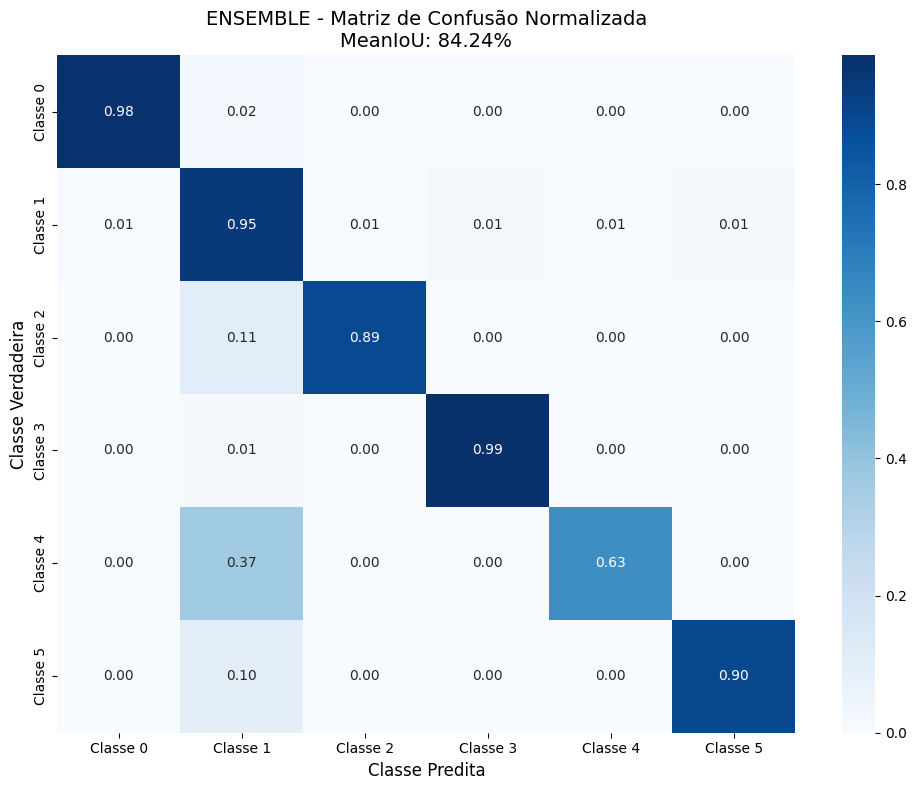

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

y_true_flat = y_val.flatten()
y_pred_flat = pred_ensemble_filtered.flatten()

cm = tf.math.confusion_matrix(y_true_flat, y_pred_flat, num_classes=NUM_CLASSES)
cm_np = cm.numpy()

iou_list = []
print("IoU por Classe (ENSEMBLE + Pós):")
for i in range(NUM_CLASSES):
    tp = tf.cast(cm[i, i], tf.float32)
    fp = tf.cast(tf.reduce_sum(cm[:, i]), tf.float32) - tp
    fn = tf.cast(tf.reduce_sum(cm[i, :]), tf.float32) - tp
    iou = tp / (tp + fp + fn + 1e-7)
    iou_list.append(iou.numpy())
    print(f"  Classe {i} IoU: {float(iou.numpy()) * 100:.2f}%")

final_iou_ensemble = float(np.mean(iou_list))
print(f"MeanIoU ENSEMBLE (val): {final_iou_ensemble * 100:.2f}%")

# Matriz de confusão normalizada
cm_sum = cm_np.sum(axis=1)[:, np.newaxis]
cm_normalized = cm_np.astype('float') / (cm_sum + 1e-7)
class_labels = [f'Classe {i}' for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title(f"ENSEMBLE - Matriz de Confusão Normalizada\nMeanIoU: {final_iou_ensemble*100:.2f}%", fontsize=14)
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()
plt.show()


Plotando exemplos: Input | GT | UNet++ | DeepLab | Ensemble...


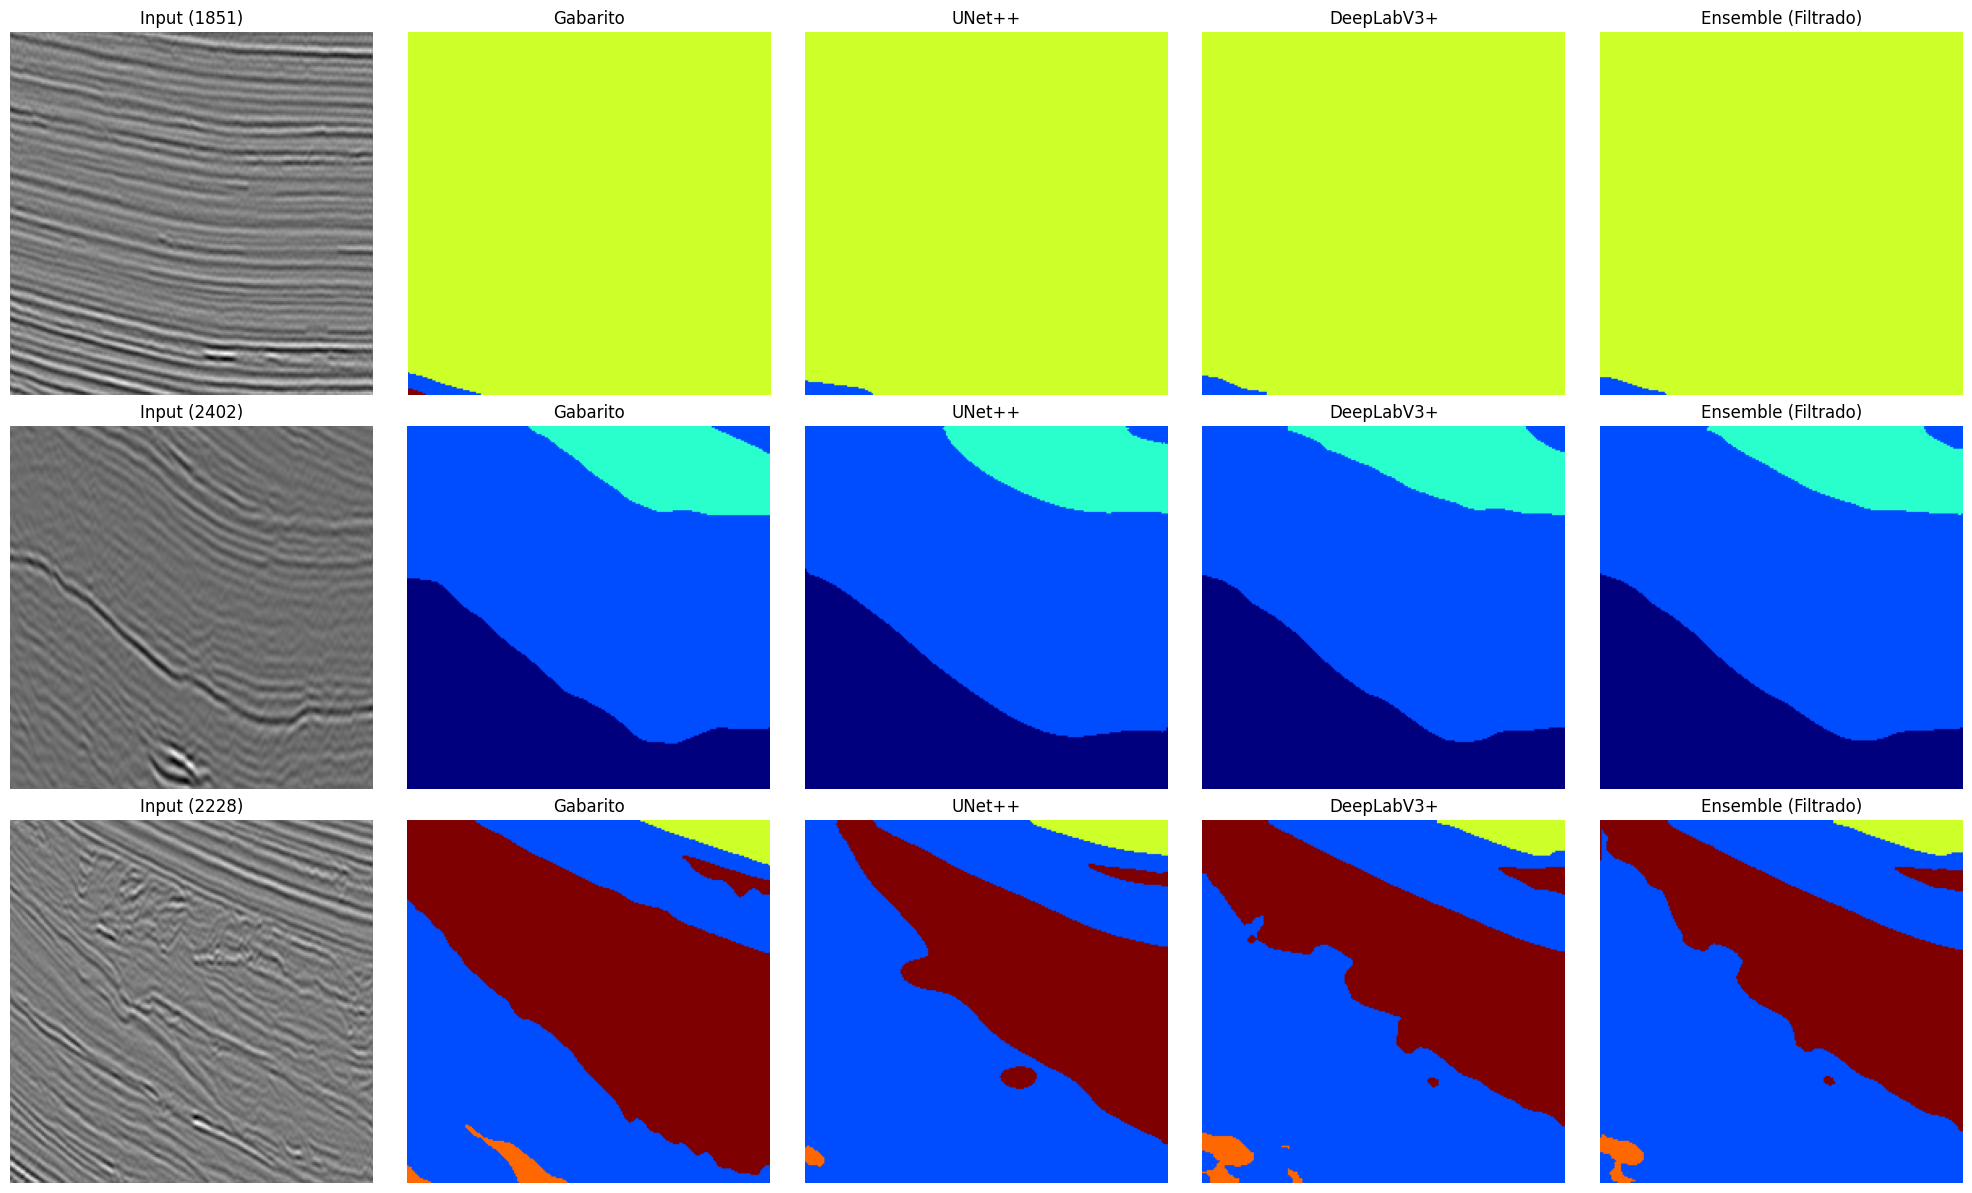

In [25]:
print("Plotando exemplos: Input | GT | UNet++ | DeepLab | Ensemble...")

num_examples = 3
indices = np.random.choice(len(X_val), num_examples, replace=False)
cols = 6 if pred_unetpp_raw_val is not None else 5

plt.figure(figsize=(4 * cols, 4 * num_examples))

for i, idx in enumerate(indices):
    col = 1

    # Input
    plt.subplot(num_examples, cols, i*cols + col)
    plt.imshow(X_val[idx, :, :, 0], cmap='gray')
    plt.title(f"Input ({idx})")
    plt.axis('off'); col += 1

    # GT
    plt.subplot(num_examples, cols, i*cols + col)
    plt.imshow(y_val[idx], cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
    plt.title("Gabarito")
    plt.axis('off'); col += 1

    # U-Net++ (se existir)
    if pred_unetpp_raw_val is not None:
        plt.subplot(num_examples, cols, i*cols + col)
        plt.imshow(pred_unetpp_raw_val[idx], cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
        plt.title("UNet++")
        plt.axis('off'); col += 1

    # DeepLab
    plt.subplot(num_examples, cols, i*cols + col)
    plt.imshow(pred_deep_raw_val[idx], cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
    plt.title("DeepLabV3+")
    plt.axis('off'); col += 1

    # Ensemble filtrado
    plt.subplot(num_examples, cols, i*cols + col)
    plt.imshow(pred_ensemble_filtered[idx], cmap='jet', vmin=0, vmax=NUM_CLASSES-1)
    plt.title("Ensemble (Filtrado)")
    plt.axis('off')

plt.tight_layout()
plt.show()


# head de embedding

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ajuste se já tiver isso em outro lugar
NUM_CLASSES = 6
CLASS_NAMES = [f"c{i}" for i in range(NUM_CLASSES)]

def metrics_from_confusion(cm):
    num_classes = cm.shape[0]
    prec, rec, f1, iou = [], [], [], []

    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision_c = tp / (tp + fp + 1e-8)
        recall_c    = tp / (tp + fn + 1e-8)
        f1_c        = 2 * precision_c * recall_c / (precision_c + recall_c + 1e-8)

        union       = tp + fp + fn
        iou_c       = tp / (union + 1e-8)

        prec.append(precision_c)
        rec.append(recall_c)
        f1.append(f1_c)
        iou.append(iou_c)

    return np.array(prec), np.array(rec), np.array(f1), np.array(iou)

def plot_confusion_matrix(cm, class_names, title):
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm_norm, interpolation="nearest")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Verdadeiro")
    ax.set_title(title + " (normalizado)")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6)

    plt.tight_layout()
    plt.show()

def plot_metrics_bar(prec, rec, f1, iou, class_names, title):
    x = np.arange(len(class_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x - 3*width/2, prec, width, label="Precision")
    ax.bar(x - width/2,   rec,  width, label="Recall")
    ax.bar(x + width/2,   f1,   width, label="F1")
    ax.bar(x + 3*width/2, iou,  width, label="IoU")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("valor")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [27]:
# Flatten do ground truth
y_true_flat = y_val.reshape(-1)

# Flatten das predições
y_att_flat   = pred_att_raw_val.reshape(-1)
y_deep_flat  = pred_deep_raw_val.reshape(-1)
y_ens_flat   = pred_ensemble_raw.reshape(-1)
y_unetpp_flat = pred_unetpp_raw_val.reshape(-1) if logits_unetpp_val is not None else None

cms = {}
metrics_all = {}

def avalia_modelo(nome, y_pred_flat):
    cm = confusion_matrix(y_true_flat, y_pred_flat,
                          labels=np.arange(NUM_CLASSES))
    cms[nome] = cm

    prec, rec, f1, iou = metrics_from_confusion(cm)
    metrics_all[nome] = {"prec":prec, "rec":rec, "f1":f1, "iou":iou}

    print("\n", "="*40, nome, "="*40)
    print("Precision por classe:", prec)
    print("Recall    por classe:", rec)
    print("F1        por classe:", f1)
    print("IoU       por classe:", iou)
    print("F1 médio :", np.mean(f1))
    print("IoU médio:", np.mean(iou))

    plot_confusion_matrix(cm, CLASS_NAMES, f"Matriz de confusão - {nome}")
    plot_metrics_bar(prec, rec, f1, iou, CLASS_NAMES,
                     f"Métricas por classe - {nome}")

# Avalia cada um
avalia_modelo("ATT-UNet",  y_att_flat)

if y_unetpp_flat is not None:
    avalia_modelo("UNet++", y_unetpp_flat)

avalia_modelo("DeepLabV3+", y_deep_flat)
avalia_modelo("Ensemble (média logits)", y_ens_flat)


NameError: name 'pred_att_raw_val' is not defined

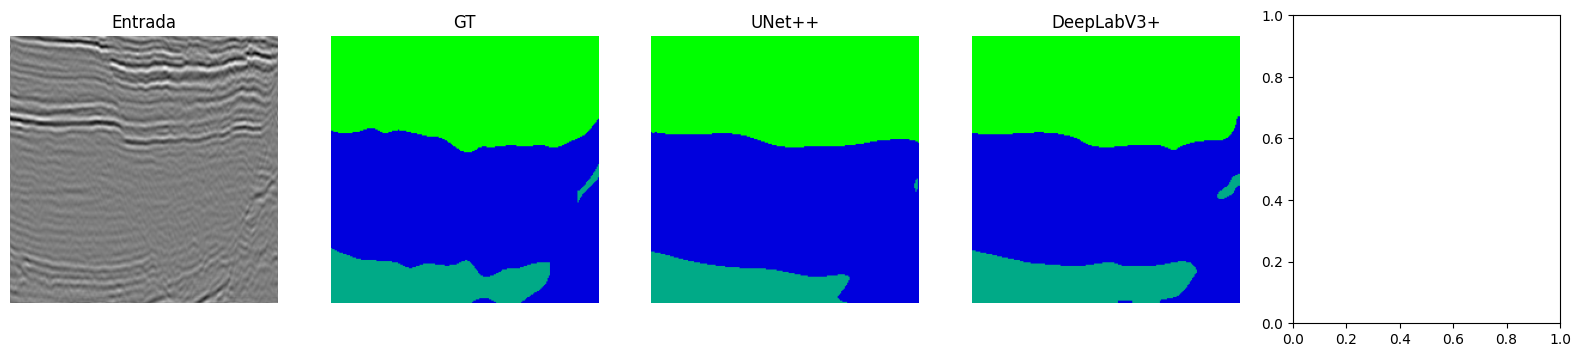

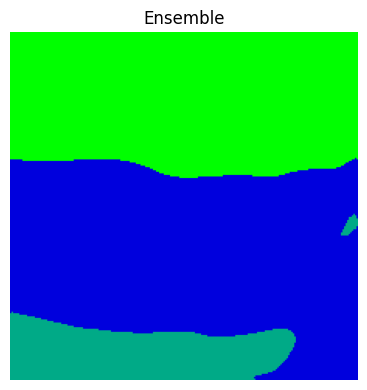

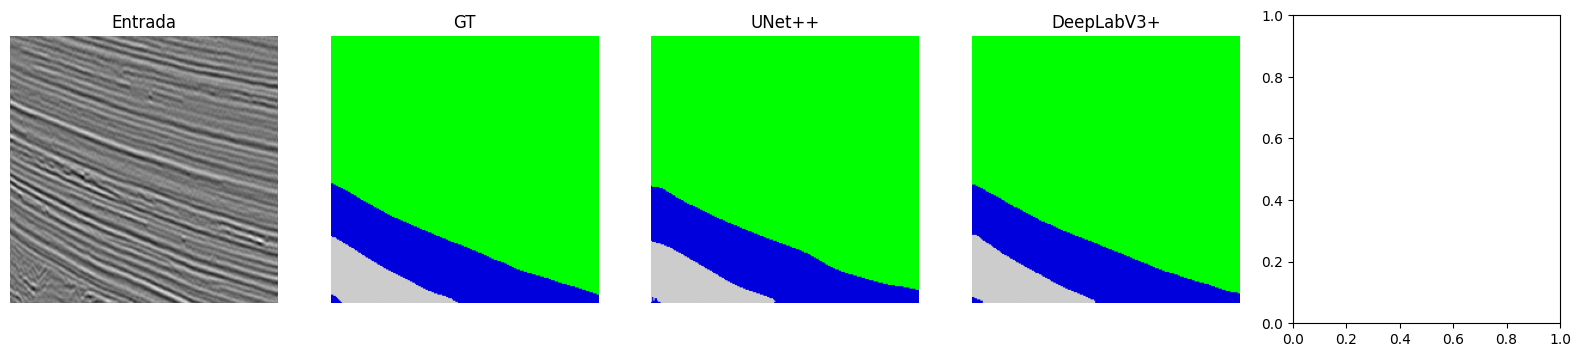

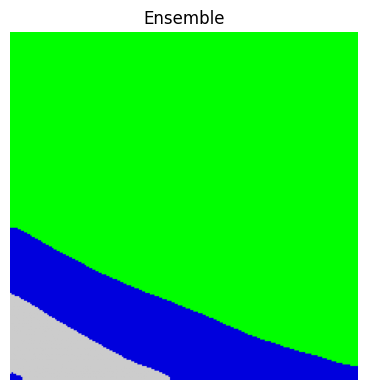

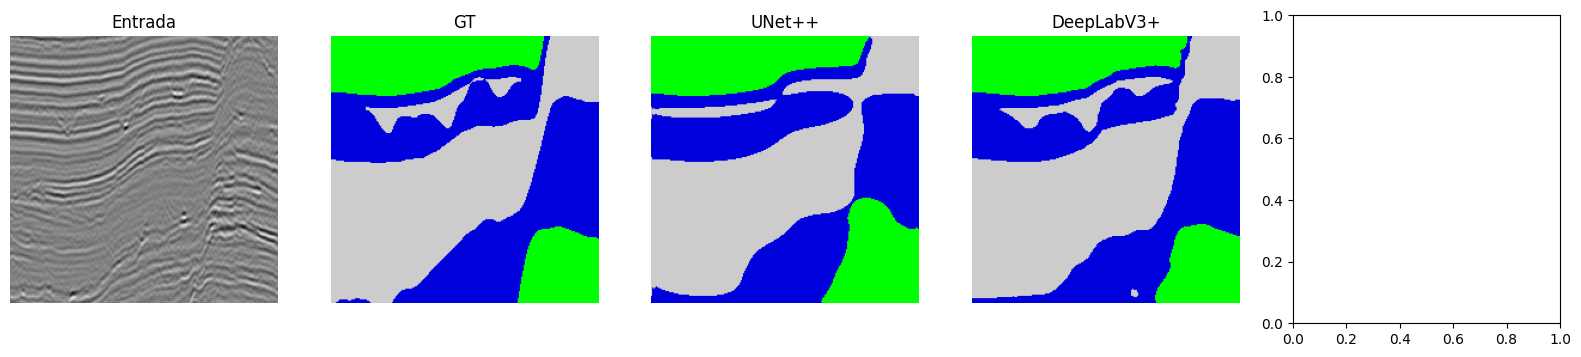

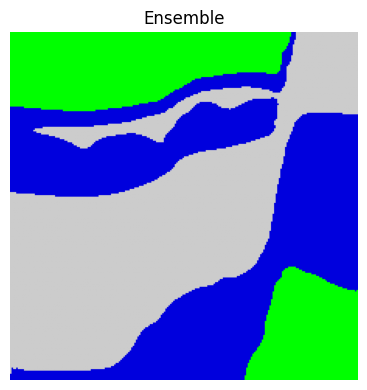

In [29]:
def show_sample_with_ensemble(idx):
    x = X_val[idx]      # (H,W,C)
    y_true = y_val[idx] # (H,W)

    # Escolher um canal pra visualizar a sísmica (se tiver multi-canal)
    if x.ndim == 3 and x.shape[-1] > 1:
        img_vis = x[..., 0]
    else:
        img_vis = x.squeeze()

    pred_deep    = pred_deep_raw_val[idx]
    pred_ens     = pred_ensemble_raw[idx]
    pred_unetpp  = pred_unetpp_raw_val[idx] if logits_unetpp_val is not None else None

    # define quantas colunas vamos plotar
    n_cols = 5 if pred_unetpp is not None else 4

    fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4))

    axes[0].imshow(img_vis, cmap="gray")
    axes[0].set_title("Entrada")
    axes[0].axis("off")

    axes[1].imshow(y_true, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES-1)
    axes[1].set_title("Gabarito")
    axes[1].axis("off")

    col = 1
    if pred_unetpp is not None:
        axes[col].imshow(pred_unetpp, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES-1)
        axes[col].set_title("UNet++")
        axes[col].axis("off")
        col += 1

    axes[col].imshow(pred_deep, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES-1)
    axes[col].set_title("DeepLabV3+")
    axes[col].axis("off")

    if pred_unetpp is not None:
        # adicionar mais uma figura para o ensemble
        fig2, ax2 = plt.subplots(1, 1, figsize=(4,4))
        ax2.imshow(pred_ens, cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES-1)
        ax2.set_title("Ensemble")
        ax2.axis("off")
    else:
        pass

    plt.tight_layout()
    plt.show()

# Exemplos:
show_sample_with_ensemble(0)
show_sample_with_ensemble(50)
show_sample_with_ensemble(100)


# model minerva 

In [30]:
import tensorflow as tf
from tensorflow.keras import backend as K

def sparse_focal_loss_with_class_weights(gamma=2.0, class_weights=None):
    """
    Focal loss + pesos por classe, para rótulo inteiro (sparse).
    class_weights: array shape (num_classes,) – ex: [1,1,1.5,1.5,4,1.5]
    """
    class_weights = tf.constant(class_weights, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        # y_true: (B,H,W), inteiros
        # y_pred: (B,H,W,C), logits
        y_true = tf.cast(y_true, tf.int32)

        # one-hot
        num_classes = tf.shape(y_pred)[-1]
        y_true_oh = tf.one_hot(y_true, depth=num_classes)       # (B,H,W,C)

        # softmax + clipping
        p = tf.nn.softmax(y_pred, axis=-1)
        p = tf.clip_by_value(p, 1e-7, 1.0 - 1e-7)

        # cross-entropy por pixel + classe
        ce = -y_true_oh * tf.math.log(p)                        # (B,H,W,C)
        ce_sum = tf.reduce_sum(ce, axis=-1)                     # (B,H,W)

        # peso por classe (broadcast)
        weights = tf.reduce_sum(y_true_oh * class_weights, axis=-1)  # (B,H,W)
        ce_weighted = ce_sum * weights

        # focal mod
        p_t = tf.reduce_sum(y_true_oh * p, axis=-1)             # (B,H,W)
        focal_factor = (1.0 - p_t) ** gamma

        loss = focal_factor * ce_weighted                       # (B,H,W)
        return tf.reduce_mean(loss)

    return loss_fn

In [32]:
class_weights = [1.0971621, 0.39005172, 4.0935616, 0.57818365, 23.811293, 1.9647989]  # mais peso na 4
loss_seg = sparse_focal_loss_with_class_weights(
    gamma=2.0,
    class_weights=class_weights
)

In [33]:
def conv_block(x, filters, name_prefix):
    x = Conv2D(filters, (3,3), padding="same", name=f"{name_prefix}_conv1")(x)
    x = BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = Activation("relu", name=f"{name_prefix}_relu1")(x)

    x = Conv2D(filters, (3,3), padding="same", name=f"{name_prefix}_conv2")(x)
    x = BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = Activation("relu", name=f"{name_prefix}_relu2")(x)
    return x

def build_shared_encoder(inputs):
    # level 1
    c1 = conv_block(inputs, 32, "enc1")
    p1 = tf.keras.layers.MaxPooling2D((2,2), name="pool1")(c1)

    # level 2
    c2 = conv_block(p1, 64, "enc2")
    p2 = tf.keras.layers.MaxPooling2D((2,2), name="pool2")(c2)

    # level 3
    c3 = conv_block(p2, 128, "enc3")
    p3 = tf.keras.layers.MaxPooling2D((2,2), name="pool3")(c3)

    # level 4
    c4 = conv_block(p3, 256, "enc4")
    p4 = tf.keras.layers.MaxPooling2D((2,2), name="pool4")(c4)

    # bottom
    b = conv_block(p4, 512, "bottom")

    skips = [c1, c2, c3, c4]
    return b, skips

In [34]:
from tensorflow.keras.layers import Add, Multiply

def attention_gate(x, g, inter_channels, name_prefix):
    """
    x: skip connection
    g: gating (vem do decoder)
    """
    theta_x = Conv2D(inter_channels, (1,1), padding="same",
                     name=f"{name_prefix}_theta_x")(x)
    phi_g   = Conv2D(inter_channels, (1,1), padding="same",
                     name=f"{name_prefix}_phi_g")(g)

    add = Add(name=f"{name_prefix}_add")([theta_x, phi_g])
    act = Activation("relu", name=f"{name_prefix}_relu")(add)
    psi = Conv2D(1, (1,1), padding="same",
                 activation="sigmoid", name=f"{name_prefix}_psi")(act)

    out = Multiply(name=f"{name_prefix}_mul")([x, psi])
    return out


In [35]:
def unet_decoder(bottleneck, skips, num_classes, name_prefix="unet"):
    c1, c2, c3, c4 = skips

    u4 = UpSampling2D((2,2), name=f"{name_prefix}_up4")(bottleneck)
    u4 = Concatenate(name=f"{name_prefix}_concat4")([u4, c4])
    c_d4 = conv_block(u4, 256, f"{name_prefix}_dec4")

    u3 = UpSampling2D((2,2), name=f"{name_prefix}_up3")(c_d4)
    u3 = Concatenate(name=f"{name_prefix}_concat3")([u3, c3])
    c_d3 = conv_block(u3, 128, f"{name_prefix}_dec3")

    u2 = UpSampling2D((2,2), name=f"{name_prefix}_up2")(c_d3)
    u2 = Concatenate(name=f"{name_prefix}_concat2")([u2, c2])
    c_d2 = conv_block(u2, 64, f"{name_prefix}_dec2")

    u1 = UpSampling2D((2,2), name=f"{name_prefix}_up1")(c_d2)
    u1 = Concatenate(name=f"{name_prefix}_concat1")([u1, c1])
    c_d1 = conv_block(u1, 32, f"{name_prefix}_dec1")

    out = Conv2D(num_classes, (1,1), padding="same",
                 name=f"{name_prefix}_logits")(c_d1)
    return out


In [36]:
def att_unet_decoder(bottleneck, skips, num_classes, name_prefix="att"):
    c1, c2, c3, c4 = skips

    # nível 4
    u4 = UpSampling2D((2,2), name=f"{name_prefix}_up4")(bottleneck)
    g4 = Conv2D(256, (1,1), padding="same", name=f"{name_prefix}_g4")(u4)
    c4_att = attention_gate(c4, g4, inter_channels=256, name_prefix=f"{name_prefix}_att4")
    u4 = Concatenate(name=f"{name_prefix}_concat4")([u4, c4_att])
    c_d4 = conv_block(u4, 256, f"{name_prefix}_dec4")

    # nível 3
    u3 = UpSampling2D((2,2), name=f"{name_prefix}_up3")(c_d4)
    g3 = Conv2D(128, (1,1), padding="same", name=f"{name_prefix}_g3")(u3)
    c3_att = attention_gate(c3, g3, inter_channels=128, name_prefix=f"{name_prefix}_att3")
    u3 = Concatenate(name=f"{name_prefix}_concat3")([u3, c3_att])
    c_d3 = conv_block(u3, 128, f"{name_prefix}_dec3")

    # nível 2
    u2 = UpSampling2D((2,2), name=f"{name_prefix}_up2")(c_d3)
    g2 = Conv2D(64, (1,1), padding="same", name=f"{name_prefix}_g2")(u2)
    c2_att = attention_gate(c2, g2, inter_channels=64, name_prefix=f"{name_prefix}_att2")
    u2 = Concatenate(name=f"{name_prefix}_concat2")([u2, c2_att])
    c_d2 = conv_block(u2, 64, f"{name_prefix}_dec2")

    # nível 1
    u1 = UpSampling2D((2,2), name=f"{name_prefix}_up1")(c_d2)
    g1 = Conv2D(32, (1,1), padding="same", name=f"{name_prefix}_g1")(u1)
    c1_att = attention_gate(c1, g1, inter_channels=32, name_prefix=f"{name_prefix}_att1")
    u1 = Concatenate(name=f"{name_prefix}_concat1")([u1, c1_att])
    c_d1 = conv_block(u1, 32, f"{name_prefix}_dec1")

    out = Conv2D(num_classes, (1,1), padding="same",
                 name=f"{name_prefix}_logits")(c_d1)
    return out


In [37]:
from tensorflow.keras.layers import Conv2D, Concatenate

def aspp_block(x, filters, name_prefix="aspp"):
    # 1x1
    p1 = Conv2D(filters, (1,1), padding="same", activation="relu",
                name=f"{name_prefix}_p1")(x)
    # 3x3 dilatados
    p2 = Conv2D(filters, (3,3), padding="same", dilation_rate=6,
                activation="relu", name=f"{name_prefix}_p2")(x)
    p3 = Conv2D(filters, (3,3), padding="same", dilation_rate=12,
                activation="relu", name=f"{name_prefix}_p3")(x)
    p4 = Conv2D(filters, (3,3), padding="same", dilation_rate=18,
                activation="relu", name=f"{name_prefix}_p4")(x)

    # concatena todos
    cat = Concatenate(name=f"{name_prefix}_concat")([p1, p2, p3, p4])

    # projeção 1x1 pra reduzir canais
    out = Conv2D(filters, (1,1), padding="same", activation="relu",
                 name=f"{name_prefix}_proj")(cat)
    return out


In [39]:
from tensorflow.keras.layers import UpSampling2D

def deeplab_decoder(bottleneck, num_classes, name_prefix="deeplab"):
    a = aspp_block(bottleneck, 256, name_prefix=f"{name_prefix}_aspp")

    # upsample progressivo até voltar pra resolução original
    u1 = UpSampling2D((2,2), interpolation="bilinear", name=f"{name_prefix}_up1")(a)
    c1 = conv_block(u1, 256, f"{name_prefix}_dec1")

    u2 = UpSampling2D((2,2), interpolation="bilinear", name=f"{name_prefix}_up2")(c1)
    c2 = conv_block(u2, 128, f"{name_prefix}_dec2")

    u3 = UpSampling2D((2,2), interpolation="bilinear", name=f"{name_prefix}_up3")(c2)
    c3 = conv_block(u3, 64, f"{name_prefix}_dec3")

    u4 = UpSampling2D((2,2), interpolation="bilinear", name=f"{name_prefix}_up4")(c3)
    c4 = conv_block(u4, 32, f"{name_prefix}_dec4")

    out = Conv2D(num_classes, (1,1), padding="same",
                 name=f"{name_prefix}_logits")(c4)
    return out


In [40]:
def build_multi_branch_model(input_shape, num_classes):
    inputs = Input(shape=input_shape, name="input_sismica")

    bottleneck, skips = build_shared_encoder(inputs)

    # 3 decoders
    logits_att   = att_unet_decoder(bottleneck, skips, num_classes, name_prefix="att")
    logits_unet  = unet_decoder(bottleneck,    skips, num_classes, name_prefix="unetpp")
    logits_deep  = deeplab_decoder(bottleneck,     num_classes,    name_prefix="deeplab")

    # nomear saídas finais claramente
    att_out    = logits_att    # (B,H,W,C)
    unetpp_out = logits_unet
    deeplab_out= logits_deep

    model = Model(inputs=inputs,
                  outputs=[att_out, unetpp_out, deeplab_out],
                  name="multi_branch_sismico")
    return model

multi_model = build_multi_branch_model(INPUT_SHAPE, NUM_CLASSES)
multi_model.summary()


Model: "multi_branch_sismico"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sismica       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 224, 224,  │        896 │ input_sismica[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 224, 224,  │        128 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 224, 224,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 224, 224,  │      9,248 │ enc1_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 224, 224,  │        128 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2          │ (None, 224, 224,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 112, 112,  │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 112, 112,  │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 112, 112,  │        256 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1          │ (None, 112, 112,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 112, 112,  │     36,928 │ enc2_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 112, 112,  │        256 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2          │ (None, 112, 112,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 56, 56,    │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 56, 56,    │     73,856 │ pool2[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 56, 56,    │        512 │ enc3_conv1[0][0]

 Total params: 17,045,814 (65.02 MB)

 Trainable params: 17,036,086 (64.99 MB)

 Non-trainable params: 9,728 (38.00 KB)

In [41]:
import numpy as np

def compute_patch_indices_with_class(y, cls=4):
    """
    y: (N,H,W) inteiro
    retorna idx com e sem a classe cls
    """
    has_cls = (y == cls).any(axis=(1,2))  # (N,)
    idx_min = np.where(has_cls)[0]
    idx_maj = np.where(~has_cls)[0]
    return idx_min, idx_maj

def balanced_batch_generator(X, y,
                             batch_size=8,
                             minority_class=4,
                             minority_frac=0.5,
                             shuffle=True):
    """
    Gera batches (X_batch, y_batch_dict) balanceando presença da classe minority_class.
    minority_frac: fração de patches do batch que terão a classe minoritária.
    """
    N = X.shape[0]
    idx_min, idx_maj = compute_patch_indices_with_class(y, cls=minority_class)

    while True:
        if shuffle:
            np.random.shuffle(idx_min)
            np.random.shuffle(idx_maj)

        n_min = int(batch_size * minority_frac)
        n_maj = batch_size - n_min

        # se faltar índice, reamostra com reposição
        if len(idx_min) < n_min:
            batch_min_idx = np.random.choice(idx_min, size=n_min, replace=True)
        else:
            batch_min_idx = np.random.choice(idx_min, size=n_min, replace=False)

        if len(idx_maj) < n_maj:
            batch_maj_idx = np.random.choice(idx_maj, size=n_maj, replace=True)
        else:
            batch_maj_idx = np.random.choice(idx_maj, size=n_maj, replace=False)

        batch_idx = np.concatenate([batch_min_idx, batch_maj_idx])
        np.random.shuffle(batch_idx)

        Xb = X[batch_idx]
        yb = y[batch_idx]

        # como o modelo tem 3 saídas, passamos o mesmo rótulo para todas
        y_dict = {
            "att_logits":    yb,
            "unetpp_logits": yb,
            "deeplab_logits":yb,
        }

        # se os nomes exatos forem diferentes, ajuste as keys:
        # use multi_model.output_names para ver
        yield Xb, y_dict


In [42]:
from tensorflow.keras.optimizers import Adam

multi_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "att_logits":     loss_seg,
        "unetpp_logits":  loss_seg,
        "deeplab_logits": loss_seg,
    },
    loss_weights={   # λ1, λ2, λ3
        "att_logits":     0.33,
        "unetpp_logits":  0.33,
        "deeplab_logits": 0.34,
    },
    metrics={
        "att_logits":     ["sparse_categorical_accuracy"],
        "unetpp_logits":  ["sparse_categorical_accuracy"],
        "deeplab_logits": ["sparse_categorical_accuracy"],
    }
)


In [43]:
X_train = X_train_multi_channel   # (N,H,W,C)
y_train = seismic_labels          # (N,H,W)


In [44]:
MINORITY_CLS = 4  # 

In [ ]:
BATCH_SIZE   = 32
MIN_FRAC     = 0.5   # 50% dos patches do batch com classe 4
EPOCHS       = 30

train_gen = balanced_batch_generator(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    minority_class=MINORITY_CLS,
    minority_frac=MIN_FRAC
)

steps_per_epoch = len(X_train) // BATCH_SIZE

history_multi = multi_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    # validation_data=... (pode usar gerador normal sem balanceamento pro val),
)


Epoch 1/30


2025-11-14 17:26:25.432581: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2025-11-14 17:26:26.432682: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng5{} for conv (f32[10368,512,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[10368,256,1,1]{3,2,1,0}, f32[256,512,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNo

588/588 ━━━━━━━━━━━━━━━━━━━━ 184s 229ms/step - att_logits_loss: 0.1880 - att_logits_sparse_categorical_accuracy: 0.7353 - deeplab_logits_loss: 0.1500 - deeplab_logits_sparse_categorical_accuracy: 0.7879 - loss: 0.1724 - unetpp_logits_loss: 0.1799 - unetpp_logits_sparse_categorical_accuracy: 0.7466
Epoch 2/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 139s 237ms/step - att_logits_loss: 0.0439 - att_logits_sparse_categorical_accuracy: 0.9138 - deeplab_logits_loss: 0.0373 - deeplab_logits_sparse_categorical_accuracy: 0.9202 - loss: 0.0419 - unetpp_logits_loss: 0.0445 - unetpp_logits_sparse_categorical_accuracy: 0.9120
Epoch 3/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 144s 245ms/step - att_logits_loss: 0.0259 - att_logits_sparse_categorical_accuracy: 0.9444 - deeplab_logits_loss: 0.0236 - deeplab_logits_sparse_categorical_accuracy: 0.9449 - loss: 0.0252 - unetpp_logits_loss: 0.0260 - unetpp_logits_sparse_categorical_accuracy: 0.9441
Epoch 4/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 142s 242ms/step - att_logits_loss: 0.0423

# Ckeckpoint

In [ ]:
y_val_dict = {
    "unetpp_logits":  y_val,
    "deeplab_logits": y_val,
}


In [ ]:
from keras.callbacks import ModelCheckpoint

ckpt = ModelCheckpoint(
    "multi_branch_sismico_best_teste.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)


In [ ]:
import matplotlib.pyplot as plt

def plot_history_loss(history):
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="train loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history_loss(history_multi)


In [ ]:
def plot_branch_losses(history):
    plt.figure(figsize=(8,4))
    for k in ["unetpp_logits_loss", "deeplab_logits_loss"]:
        if k in history.history:
            plt.plot(history.history[k], label=k)
    plt.xlabel("Época")
    plt.ylabel("Loss por cabeça")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_branch_losses(history_multi)


In [ ]:
def plot_branch_losses_with_val(history, branch_prefix):
    # branch_prefix: "unetpp_logits" ou "deeplab_logits"
    train_key = f"{branch_prefix}_loss"
    val_key   = f"val_{branch_prefix}_loss"

    plt.figure(figsize=(6,4))
    if train_key in history.history:
        plt.plot(history.history[train_key], label=f"{branch_prefix} train")
    if val_key in history.history:
        plt.plot(history.history[val_key], label=f"{branch_prefix} val")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_branch_losses_with_val(history_multi, "unetpp_logits")
plot_branch_losses_with_val(history_multi, "deeplab_logits")


In [ ]:
def plot_branch_acc(history):
    plt.figure(figsize=(8,4))
    for k in [
        "unetpp_logits_sparse_categorical_accuracy",
        "deeplab_logits_sparse_categorical_accuracy",
    ]:
        if k in history.history:
            plt.plot(history.history[k], label=k)
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_branch_acc(history_multi)


In [ ]:
def plot_branch_acc_with_val(history, branch_prefix):
    train_key = f"{branch_prefix}_sparse_categorical_accuracy"
    val_key   = f"val_{branch_prefix}_sparse_categorical_accuracy"

    plt.figure(figsize=(6,4))
    if train_key in history.history:
        plt.plot(history.history[train_key], label=f"{branch_prefix} acc train")
    if val_key in history.history:
        plt.plot(history.history[val_key], label=f"{branch_prefix} acc val")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_branch_acc_with_val(history_multi, "unetpp_logits")
plot_branch_acc_with_val(history_multi, "deeplab_logits")

In [ ]:
np.unique(seismic_labels, return_counts=True)

In [ ]:
from sklearn.utils import class_weight

y_train_flat = seismic_labels.flatten() 
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

# Converter para um dicionário que o Keras entende
class_weights = {i: class_weights_array[i] for i in range(NUM_CLASSES)}

print(f"Pesos de Classe calculados: {class_weights}")